# MicroSim snapshot visualization

This notebook loads saved outputs from `MicroSim.jl` and provides a few ways to inspect the simulation snapshots:

- quick metadata / shape checks
- static plots for selected snapshot indices
- a time-series browser with a slider
- optional mesoscopic averaging
- a simple animation preview

Expected files in the output directory:
- `occupancies_t.npy`
- `tau_t.npy`
- optionally `cache.npy`, `chemo_rates1.npy`, `chemo_rates2.npy`


In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

try:
    import ipywidgets as widgets
    from IPython.display import display
    HAS_WIDGETS = True
except Exception:
    HAS_WIDGETS = False

plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["axes.grid"] = True


## 1. Set the simulation output directory

In [2]:
base_dir = Path("/scratch.local/gtucci/micro/julia")

folders = sorted([p for p in base_dir.iterdir() if p.is_dir()])

for i, f in enumerate(folders):
    print(i, f.name)

0 l1_15.00_Dn1_0.80_T_10.00_2026-04-10_115702
1 l1_15.00_Dn1_0.80_T_100.00_2026-04-10_120557
2 l1_15.00_Dn1_0.80_T_200.00_2026-04-10_140428
3 l1_25.00_Dn1_0.80_T_100.00_2026-04-11_094043


In [3]:

# Set this to one of your MicroSim output folders.
# Example:
#data_dir = Path("/scratch.local/gtucci/micro/lambda1_15.0/Dn1_0.8/T_1.0")
#data_dir = Path("PATH_TO_OUTPUT_DIR")

data_dir = folders[3] 

occupancies_path = data_dir / "occupancies_t.npy"
tau_path = data_dir / "tau_t.npy"

assert occupancies_path.exists(), f"Missing file: {occupancies_path}"
assert tau_path.exists(), f"Missing file: {tau_path}"

print("Using data directory:", data_dir)


Using data directory: /scratch.local/gtucci/micro/julia/l1_25.00_Dn1_0.80_T_100.00_2026-04-11_094043


## 2. Load arrays

In [4]:

occupancies_t = np.load(occupancies_path)
tau_t = np.load(tau_path)

cache = None
cache_path = data_dir / "cache.npy"
if cache_path.exists():
    cache = np.load(cache_path)

chemo_rates1 = None
chemo_rates2 = None
for name in ["chemo_rates1.npy", "chemo_rates2.npy"]:
    p = data_dir / name
    if p.exists():
        if name == "chemo_rates1.npy":
            chemo_rates1 = np.load(p)
        else:
            chemo_rates2 = np.load(p)

print("occupancies_t shape:", occupancies_t.shape)
print("tau_t shape:", tau_t.shape)
if cache is not None:
    print("cache shape:", cache.shape, "dtype:", cache.dtype)
if chemo_rates1 is not None:
    print("chemo_rates1 shape:", chemo_rates1.shape)
if chemo_rates2 is not None:
    print("chemo_rates2 shape:", chemo_rates2.shape)

assert occupancies_t.ndim == 3, "Expected occupancies_t with shape (nt, nfields, nsites)"
assert occupancies_t.shape[0] == len(tau_t), "First dimension of occupancies_t must match tau_t length"

nt, nfields, nsites = occupancies_t.shape
print(f"nt={nt}, nfields={nfields}, nsites={nsites}")


occupancies_t shape: (142870, 3, 250)
tau_t shape: (142870,)
cache shape: (2,) dtype: complex128
chemo_rates1 shape: (500,)
chemo_rates2 shape: (500,)
nt=142870, nfields=3, nsites=250


## 3. Helpers

In [5]:

def meso_avg(arr, w):
    arr = np.asarray(arr, dtype=float)
    n = arr.shape[0]
    out = np.zeros(n, dtype=float)
    for i in range(n):
        s = 0.0
        for j in range(-w, w + 1):
            s += arr[(i + j) % n]
        out[i] = s / (2 * w + 1)
    return out

def get_snapshot(idx):
    idx = int(np.clip(idx, 0, len(tau_t) - 1))
    return occupancies_t[idx], float(tau_t[idx])

def field_labels(nfields):
    default = ["n1", "n2", "chemical"]
    if nfields <= len(default):
        return default[:nfields]
    return [f"field_{i}" for i in range(nfields)]

labels = field_labels(nfields)
labels


['n1', 'n2', 'chemical']

## 4. Plot one snapshot

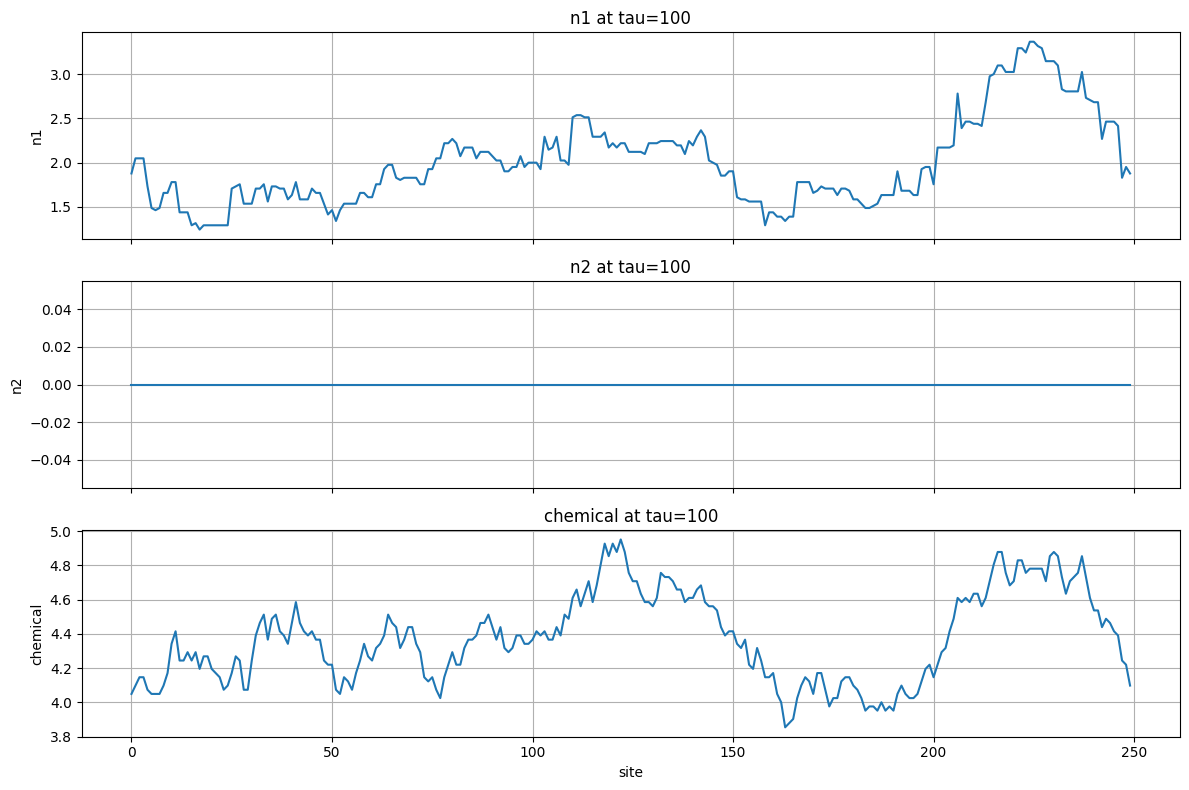

In [6]:

def plot_snapshot(idx, w=0, figsize=(12, 8), sharey=False):
    snap, tau = get_snapshot(idx)
    labels = field_labels(snap.shape[0])

    fig, axes = plt.subplots(snap.shape[0], 1, figsize=figsize, sharex=True, sharey=sharey)
    if snap.shape[0] == 1:
        axes = [axes]

    for k, ax in enumerate(axes):
        y = snap[k]
        if w > 0:
            y = meso_avg(y, w)
        ax.plot(y)
        ax.set_ylabel(labels[k])
        ax.set_title(f"{labels[k]} at tau={tau:.6g}")

    axes[-1].set_xlabel("site")
    plt.tight_layout()
    plt.show()

# Example:
plot_snapshot(len(tau_t), w=20)


## 5. Compare a few snapshots

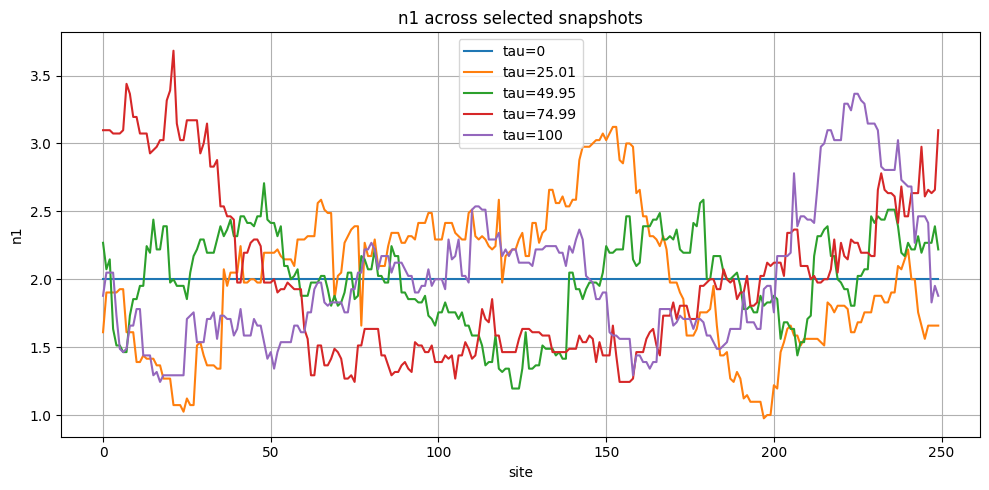

In [8]:

def plot_multiple_snapshots(indices, field=0, w=0, figsize=(10, 5)):
    labels = field_labels(nfields)
    plt.figure(figsize=figsize)
    for idx in indices:
        snap, tau = get_snapshot(idx)
        y = snap[field]
        if w > 0:
            y = meso_avg(y, w)
        plt.plot(y, label=f"tau={tau:.4g}")
    plt.title(f"{labels[field]} across selected snapshots")
    plt.xlabel("site")
    plt.ylabel(labels[field])
    plt.legend()
    plt.tight_layout()
    plt.show()

# Example:
example_indices = np.linspace(0, len(tau_t) - 1, min(5, len(tau_t)), dtype=int)
plot_multiple_snapshots(example_indices, field=0, w=20)

## 6. Interactive browser

In [ ]:

if HAS_WIDGETS:
    idx_slider = widgets.IntSlider(
        value=0, min=0, max=len(tau_t) - 1, step=1, description="snapshot"
    )
    w_slider = widgets.IntSlider(
        value=0, min=0, max=min(20, max(0, nsites // 4)), step=1, description="avg w"
    )

    ui = widgets.VBox([idx_slider, w_slider])

    out = widgets.interactive_output(
        lambda snapshot, avg_w: plot_snapshot(snapshot, w=avg_w),
        {"snapshot": idx_slider, "avg_w": w_slider},
    )

    display(ui, out)
else:
    print("ipywidgets is not available in this environment.")


## 7. Optional animation

In [ ]:

from matplotlib import animation
from IPython.display import HTML

def animate_field(field=0, w=0, stride=1, interval=100, figsize=(10, 4)):
    labels = field_labels(nfields)
    fig, ax = plt.subplots(figsize=figsize)
    x = np.arange(nsites)
    y0 = occupancies_t[0, field]
    if w > 0:
        y0 = meso_avg(y0, w)
    line, = ax.plot(x, y0)
    ax.set_xlim(0, nsites - 1)
    ymin = occupancies_t[:, field, :].min()
    ymax = occupancies_t[:, field, :].max()
    ax.set_ylim(ymin - 0.5, ymax + 0.5)
    title = ax.set_title(f"{labels[field]} at tau={tau_t[0]:.4g}")

    frames = list(range(0, len(tau_t), max(1, stride)))

    def update(i):
        y = occupancies_t[i, field]
        if w > 0:
            y = meso_avg(y, w)
        line.set_ydata(y)
        title.set_text(f"{labels[field]} at tau={tau_t[i]:.4g}")
        return line, title

    anim = animation.FuncAnimation(fig, update, frames=frames, interval=interval, blit=False)
    plt.close(fig)
    return HTML(anim.to_jshtml())

# Example:
# animate_field(field=2, w=0, stride=max(1, len(tau_t)//100), interval=80)


## 8. Quick diagnostics

In [ ]:

plt.figure(figsize=(8, 4))
plt.plot(tau_t, marker=".", ms=2)
plt.title("Saved snapshot times")
plt.xlabel("saved index")
plt.ylabel("tau")
plt.tight_layout()
plt.show()

for k, label in enumerate(labels):
    totals = occupancies_t[:, k, :].sum(axis=1)
    plt.figure(figsize=(8, 4))
    plt.plot(tau_t, totals)
    plt.title(f"Total {label} vs tau")
    plt.xlabel("tau")
    plt.ylabel(f"sum({label})")
    plt.tight_layout()
    plt.show()
